ליאור מ. (3072)

לוטם ק. (3481)

גולן ק. (7509)

אלדד ס. (6134)

בפרויקט זה אנו מתמודדים עם בעיית סיווג טקסט, שמטרתה להבחין בין הודעות זבל לבין הודעות רגילות ותקינות. מאגר הנתונים שנבחר מכיל למעלה מ-5,000 הודעות גולמיות, אשר מתאפיינות בכך שרוב הנתונים הם הודעות תקינות ורק מיעוטן הודעות זבל. לצורך פתרון הבעיה, ביצענו ניקוי של הטקסט ואיזון של הכמויות כדי לאפשר למידה יעילה. השתמשנו באלגוריתם לחיפוש שכנים קרובים שמימשנו בעצמנו, ובחנו דרכים שונות לייצוג המילים כערכים מספריים. המטרה המרכזית הייתה למצוא את השילוב המדויק ביותר שמאזן בין היכולת לתפוס הודעות זבל לבין המניעה של חסימת הודעות חשובות בטעות.

prompts we used:


"אני רואה ב-Dataset עמודות שנקראות 'Unnamed: 2', 'Unnamed: 3' ו-'Unnamed: 4' והן נראות ריקות. האם מדובר בבאג ידוע ב-CSV של Spam SMS? תסביר לי למה כדאי למחוק אותן ואיך זה משפיע על ניקוי הנתונים."

"במשימת סיווג טקסט (NLP), האם עדיף להשתמש ב-KNN עם מרחק אוקלידי או ב-Cosine Similarity? מהם היתרונות של כל אחד כשעובדים עם וקטורים של מילים?"

"בדאטה-סט המקורי יש הרבה פחות ספאם מהודעות רגילות. אם נאזן את הנתונים (Undersampling), איך זה ישפיע על ה-Base Value של המודל ועל ה-Precision שלו? האם המודל יהפוך להיות 'רגיש מדי' למילים מסוימות?"

"איך אני יכול להשתמש ב-SHAP כדי להסביר החלטה ספציפית של המודל? תסביר לי מה המשמעות של החצים בגרף ה-Force Plot ואיך מילה בודדת כמו '2000' יכולה להקפיץ את ההסתברות לספאם מעל הסף."

"אני רוצה לבצע Grid Search עם 5-Fold Cross Validation. אילו קומבינציות של Feature Engineering וערכי K כדאי לי לבדוק כדי למצוא את המודל האופטימלי לסיווג ספאם?"


In [89]:
%pip install pandas numpy scikit-learn matplotlib seaborn shap

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [90]:
import pandas as pd
import sklearn
import matplotlib.pyplot as plt

In [91]:

# Load the dataset with specific encoding for text files
df = pd.read_csv('spam.csv', encoding='latin-1')

# Remove unnecessary empty columns frequently found in this specific CSV
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], errors='ignore')

# Rename columns to meaningful names
df.columns = ['label', 'text']

# Requirement Part 1: Display the first 5 rows
print("--- Dataset Head ---")
print(df.head())

# Analyze class distribution (Ham vs Spam)
print("\n--- Label Distribution ---")
print(df['label'].value_counts())

--- Dataset Head ---
  label                                               text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

--- Label Distribution ---
label
ham     4825
spam     747
Name: count, dtype: int64


In [92]:
import pandas as pd
import string
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

df = pd.read_csv('spam.csv', encoding='latin-1')
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], errors='ignore')
df.columns = ['label', 'text']

stop_words = set(ENGLISH_STOP_WORDS)

def clean_text(text):
    text = str(text).lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    return ' '.join(word for word in text.split() if word not in stop_words)

df['cleaned_text'] = df['text'].apply(clean_text)
df[['text', 'cleaned_text']].head()


,text,cleaned_text
0,"Go until jurong point, crazy.. Available only ...",jurong point crazy available bugis n great wor...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,U dun say so early hor... U c already then say...,u dun say early hor u c say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives


In [93]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity


class SimpleKNN:
    def __init__(self, k=3):
        self.k = k
        self.X_train = None
        self.y_train = None
        self.classes_ = None

    def fit(self, X, y):
        self.X_train = X
        self.y_train = np.asarray(y)
        self.classes_ = np.unique(self.y_train)
        return self

    def predict_proba(self, X_test):
        similarities = cosine_similarity(X_test, self.X_train)
        probabilities = []

        for similarity_row in similarities:
            neighbor_indices = np.argsort(similarity_row)[-self.k:][::-1]
            neighbor_labels = self.y_train[neighbor_indices]
            class_probabilities = []

            for class_label in self.classes_:
                class_probabilities.append(np.mean(neighbor_labels == class_label))

            probabilities.append(class_probabilities)

        return np.array(probabilities)

    def predict(self, X_test):
        probabilities = self.predict_proba(X_test)
        return self.classes_[np.argmax(probabilities, axis=1)]


In [94]:
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

texts = df['cleaned_text']

# 1. Basic bag-of-words counts
count_vectorizer = CountVectorizer()
X_count = count_vectorizer.fit_transform(texts)

# 2. TF-IDF with unigrams
tfidf_unigram_vectorizer = TfidfVectorizer()
X_tfidf_unigram = tfidf_unigram_vectorizer.fit_transform(texts)

# 3. TF-IDF with unigrams and bigrams
tfidf_bigram_vectorizer = TfidfVectorizer(ngram_range=(1, 2))
X_tfidf_bigram = tfidf_bigram_vectorizer.fit_transform(texts)

# 4. TF-IDF reduced with TruncatedSVD
tfidf_svd_vectorizer = TfidfVectorizer()
X_tfidf_for_svd = tfidf_svd_vectorizer.fit_transform(texts)
svd = TruncatedSVD(n_components=100, random_state=42)
X_tfidf_svd = svd.fit_transform(X_tfidf_for_svd)

print('CountVectorizer shape:', X_count.shape)
print('TF-IDF unigram shape:', X_tfidf_unigram.shape)
print('TF-IDF bigram shape:', X_tfidf_bigram.shape)
print('TF-IDF + TruncatedSVD shape:', X_tfidf_svd.shape)


CountVectorizer shape: (5572, 9229)
TF-IDF unigram shape: (5572, 9229)
TF-IDF bigram shape: (5572, 38042)
TF-IDF + TruncatedSVD shape: (5572, 100)


In [95]:
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

X = df['cleaned_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

train_df = pd.DataFrame({'text': X_train, 'label': y_train})
ham_train = train_df[train_df['label'] == 'ham']
spam_train = train_df[train_df['label'] == 'spam']

ham_train_undersampled = resample(
    ham_train,
    replace=False,
    n_samples=len(spam_train),
    random_state=42
)

train_balanced = pd.concat([ham_train_undersampled, spam_train]).sample(
    frac=1,
    random_state=42
)

X_train_balanced = train_balanced['text']
y_train_balanced = train_balanced['label']

print('Original training class distribution:')
print(y_train.value_counts())
print('\nBalanced training class distribution:')
print(y_train_balanced.value_counts())


Original training class distribution:
label
ham     3859
spam     598
Name: count, dtype: int64

Balanced training class distribution:
label
spam    598
ham     598
Name: count, dtype: int64


In [96]:
from sklearn.base import clone
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline

vectorizer_configs = {
    'CountVectorizer': CountVectorizer(),
    'TfidfVectorizer_Unigram': TfidfVectorizer(),
    'TfidfVectorizer_Bigram': TfidfVectorizer(ngram_range=(1, 2)),
    'TfidfVectorizer_SVD100': make_pipeline(
        TfidfVectorizer(),
        TruncatedSVD(n_components=100, random_state=42)
    ),
}

k_values = [3, 5, 7, 9]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X_cv = X_train_balanced.reset_index(drop=True)
y_cv = y_train_balanced.reset_index(drop=True)

grid_search_results = []

for vectorizer_name, vectorizer in vectorizer_configs.items():
    for k in k_values:
        fold_scores = []

        for train_idx, val_idx in cv.split(X_cv, y_cv):
            X_fold_train = X_cv.iloc[train_idx]
            X_fold_val = X_cv.iloc[val_idx]
            y_fold_train = y_cv.iloc[train_idx]
            y_fold_val = y_cv.iloc[val_idx]

            current_vectorizer = clone(vectorizer)
            X_fold_train_vec = current_vectorizer.fit_transform(X_fold_train)
            X_fold_val_vec = current_vectorizer.transform(X_fold_val)

            knn = SimpleKNN(k=k)
            knn.fit(X_fold_train_vec, y_fold_train)
            y_pred = knn.predict(X_fold_val_vec)

            fold_scores.append(f1_score(y_fold_val, y_pred, average='macro'))

        grid_search_results.append({
            'Vectorizer_Type': vectorizer_name,
            'K': k,
            'Mean_F1_Score': np.mean(fold_scores)
        })

grid_search_df = pd.DataFrame(grid_search_results)
grid_search_df = grid_search_df.sort_values(
    by='Mean_F1_Score',
    ascending=False
).reset_index(drop=True)

grid_search_df


,Vectorizer_Type,K,Mean_F1_Score
0,TfidfVectorizer_Bigram,3,0.905476
1,CountVectorizer,3,0.903807
2,TfidfVectorizer_Unigram,3,0.899597
3,TfidfVectorizer_Bigram,9,0.898810
4,TfidfVectorizer_Bigram,5,0.898793
5,CountVectorizer,7,0.898778
6,TfidfVectorizer_Bigram,7,0.896280
7,CountVectorizer,9,0.895400
8,CountVectorizer,5,0.894529
9,TfidfVectorizer_Unigram,9,0.893789


Best vectorizer: TfidfVectorizer_Bigram
Best k: 3

Classification Report:
              precision    recall  f1-score   support

         ham       0.98      0.91      0.94       966
        spam       0.60      0.88      0.71       149

    accuracy                           0.90      1115
   macro avg       0.79      0.89      0.83      1115
weighted avg       0.93      0.90      0.91      1115


Explaining test message:
won 1000 cash 2000 prize claim call09050000327


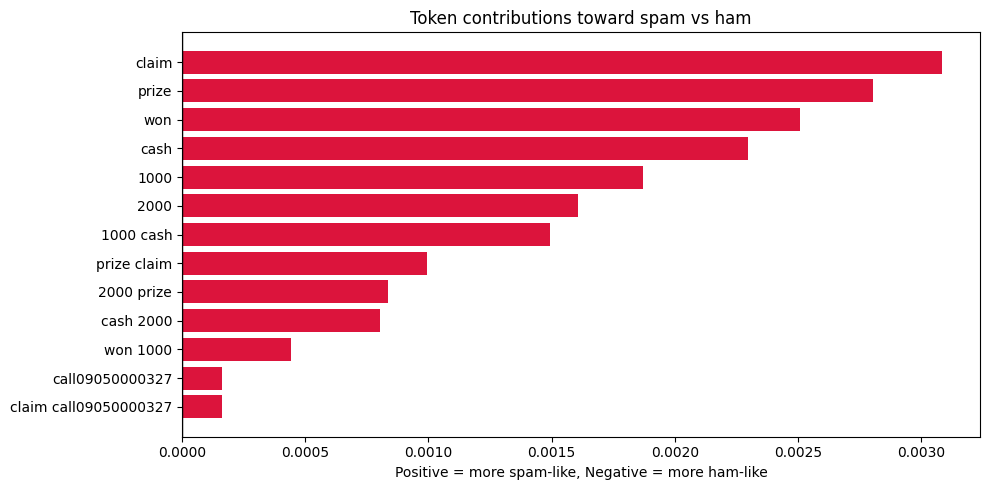

,token,tfidf_value,contribution
7,claim,0.183856,0.003083
9,prize,0.203787,0.002802
11,won,0.205496,0.002506
5,cash,0.210991,0.002298
0,1000,0.233741,0.001872
2,2000,0.247488,0.001607
1,1000 cash,0.256049,0.001493
10,prize claim,0.283009,0.000996
3,2000 prize,0.296454,0.000837
6,cash 2000,0.301853,0.000804


In [98]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report

best_result = grid_search_df.iloc[0]
best_vectorizer_name = best_result['Vectorizer_Type']
best_k = int(best_result['K'])

best_vectorizer = clone(vectorizer_configs[best_vectorizer_name])
X_train_best = best_vectorizer.fit_transform(X_train_balanced)
X_test_best = best_vectorizer.transform(X_test)

best_knn = SimpleKNN(k=best_k)
best_knn.fit(X_train_best, y_train_balanced)
y_test_pred = best_knn.predict(X_test_best)

print(f'Best vectorizer: {best_vectorizer_name}')
print(f'Best k: {best_k}')
print('\nClassification Report:')
print(classification_report(y_test, y_test_pred))

spam_predictions = X_test[y_test_pred == 'spam']
if len(spam_predictions) == 0:
    sample_index = X_test.index[0]
else:
    sample_index = spam_predictions.index[0]

sample_text = X_test.loc[sample_index]
print('\nExplaining test message:')
print(sample_text)

feature_names = best_vectorizer.get_feature_names_out()
sample_vec = best_vectorizer.transform([sample_text])

spam_mask = (y_train_balanced == 'spam').values
ham_mask = (y_train_balanced == 'ham').values

spam_mean = np.asarray(X_train_best[spam_mask].mean(axis=0)).ravel()
ham_mean = np.asarray(X_train_best[ham_mask].mean(axis=0)).ravel()

sample_array = sample_vec.toarray().ravel()
present_idx = np.where(sample_array > 0)[0]

token_rows = []
for idx in present_idx:
    token = feature_names[idx]
    token_value = sample_array[idx]
    score = token_value * (spam_mean[idx] - ham_mean[idx])
    token_rows.append({
        'token': token,
        'tfidf_value': token_value,
        'contribution': score
    })

token_data = pd.DataFrame(token_rows)

if token_data.empty:
    print('No non-zero token contributions were found for this message.')
else:
    token_data['abs_contribution'] = token_data['contribution'].abs()
    token_data = token_data.sort_values('abs_contribution', ascending=False).head(15)
    token_data = token_data.sort_values('contribution')

    plt.figure(figsize=(10, 5))
    colors = ['crimson' if v > 0 else 'steelblue' for v in token_data['contribution']]
    plt.barh(token_data['token'], token_data['contribution'], color=colors)
    plt.axvline(0, color='black', linewidth=1)
    plt.title('Token contributions toward spam vs ham')
    plt.xlabel('Positive = more spam-like, Negative = more ham-like')
    plt.tight_layout()
    plt.show()

    display(token_data[['token', 'tfidf_value', 'contribution']].sort_values('contribution', ascending=False))
